In [1]:
import scanpy as sc

In [2]:
import pandas as pd

In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np

In [4]:
#zone_fm = pd.read_csv('/tscc/lustre/ddn/scratch/welison/Liver_Share/result.depot/250131_Hepatocyte_Subtype_DESeq/RNA/Hepatocytes.Senescent_High_Fibrosis_vs_Control.dds.res', sep = '\t')


In [5]:
#filtered_df = zone_fm[(zone_fm['log2FoldChange'] > 0) & (zone_fm['padj'] < 0.1)]


In [4]:
sample_nm = 'HL20221019_broad_no_mast_filt'

In [5]:
# deep_seq_heps_alldonors_highfib_lowfib
# assigning tangram labels with high fib 3+4 donors, final iteration of sen heps

In [6]:
inp_dir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/tangram/deep_seq_heps_alldonors_highfib_lowfib/'


In [7]:
sp_file_path = os.path.join(inp_dir, sample_nm, 'merge/Post_sp_ct_proj_comb_outer.h5ad')
adata_pred_filt_cropped = sc.read_h5ad(sp_file_path)
print(adata_pred_filt_cropped)

AnnData object with n_obs × n_vars = 178400 × 17910
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types'
    uns: 'clusters', 'hvg', 'neighbors', 'pca', 'pred_cell_types_colors', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'


In [8]:
highfib_res = pd.read_csv('/tscc/lustre/ddn/scratch/welison/Liver_Share/result.depot/250131_Hepatocyte_Subtype_DESeq/RNA/Hepatocytes.Senescent_High_Fibrosis_vs_Control.dds.res', sep = "\t")

In [9]:
highfib_res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
ITGB6,14.757362,5.252562,0.615279,8.536883,1.378914e-17,2.448952e-13
BICC1,267.814158,4.715374,0.592744,7.955160,1.789008e-15,1.588639e-11
NPSR1-AS1,33.918738,5.237239,0.675110,7.757609,8.654567e-15,5.123503e-11
MAP2,106.100686,4.967114,0.647006,7.677079,1.627570e-14,6.627730e-11
PCSK5,165.571436,2.848441,0.371881,7.659546,1.865915e-14,6.627730e-11
...,...,...,...,...,...,...
IAPP,9.552972,-0.000284,0.499157,-0.000569,9.995461e-01,9.999134e-01
TMED8,26.209055,-0.000039,0.218737,-0.000179,9.998571e-01,9.999134e-01
AC092755.2,0.895134,-0.000551,0.787804,-0.000700,9.994418e-01,9.999134e-01
HOOK2,66.047202,0.000093,0.181490,0.000513,9.995905e-01,9.999134e-01


In [10]:
highfib_res_up  = highfib_res[(highfib_res['padj'] < 0.1) & (highfib_res['log2FoldChange'] > 2)]


In [11]:
hf_list = highfib_res_up.index.tolist()

In [15]:
hf_list_50 = hf_list[0:50]

In [16]:
# by pvalue LGALS3, BCL2, COL4A2, CXCL8, COL4A1, BATF, CDKN2A, CD44

In [17]:
hf_list_50

['ITGB6',
 'BICC1',
 'NPSR1-AS1',
 'MAP2',
 'PCSK5',
 'FMNL2',
 'FGF13',
 'HK1',
 'AC025159.1',
 'HSPB8',
 'LIPH',
 'AC092153.1',
 'LRRC1',
 'AL359313.1',
 'TMEM178B',
 'TXNRD1',
 'KRTAP5-AS1',
 'CD24',
 'CA12',
 'PCNX2',
 'BCL2',
 'STK39',
 'LGALS3',
 'KRT23',
 'IGF2BP2',
 'MSC-AS1',
 'PKN2-AS1',
 'COL4A2',
 'ZNF827',
 'SLC25A24',
 'DNAJC6',
 'TMEM156',
 'RASEF',
 'DAGLA',
 'LYPLAL1-DT',
 'BTBD11',
 'CXCL8',
 'PVT1',
 'MIR4435-2HG',
 'EID3',
 'TSPAN15',
 'CRIM1',
 'OSBPL3',
 'COL4A1',
 'PTCHD4',
 'BATF',
 'CDKN2A',
 'CD44',
 'AL590652.1',
 'PFKP']

In [18]:
hf_list_50_lc = [gene.lower() for gene in hf_list_50] 


In [34]:
#hf_list_50 

In [66]:
os.makedirs('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/RNA/clusterprofiler_kegg_react/top_deseq2_genes/')

In [24]:
odir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/RNA/clusterprofiler_kegg_react/top_deseq2_genes/'


In [18]:
score_name = f"RNA_sen_highfib_deseq_top50_pval_rna_multiome"

In [19]:
sc.tl.score_genes(adata_pred_filt_cropped, gene_list=hf_list_50_lc, score_name=score_name)


       'msc-as1', 'pkn2-as1', 'lyplal1-dt', 'pvt1', 'mir4435-2hg',
       'al590652.1'],
      dtype='object')


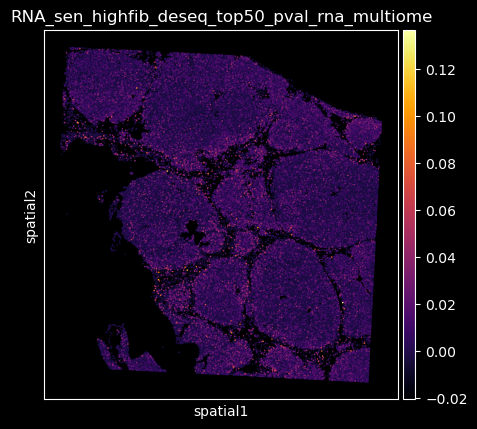

In [20]:
plt.style.use('dark_background')
sc.pl.spatial(
    adata_pred_filt_cropped, 
    color=score_name, 
    color_map="inferno", 
    show=False, 
    size=4, 
    img_key=None,
)
plt.savefig(f"{odir}{score_name}.pdf")

In [ ]:
#highfib_res_up_fc  = highfib_res[(highfib_res['padj'] < 0.1) & (highfib_res['log2FoldChange'] > 2)]


In [12]:
highfib_res_up_fc = highfib_res_up.sort_values(by='log2FoldChange', ascending=False)


In [13]:
hf_fc_list = highfib_res_up_fc.index.tolist()
hf_fc_list_50 = hf_fc_list[0:50]
hf_fc_list_50_lc = [gene.lower() for gene in hf_fc_list_50] 
score_name_fc = f"RNA_sen_highfib_deseq_top50_log2fc_rna_multiome"
sc.tl.score_genes(adata_pred_filt_cropped, gene_list=hf_fc_list_50_lc, score_name=score_name_fc)


       'linc02233', 'znf385d-as2', 'linc02477', 'al807761.4', 'dlgap1-as3',
       'linc02006', 'ap000851.1'],
      dtype='object')


In [14]:
hf_fc_list_50

['AL359313.1',
 'MSC-AS1',
 'KRT23',
 'SPP1',
 'CDH6',
 'COL4A1',
 'ITGB6',
 'NPSR1-AS1',
 'ANKRD1',
 'CXCL8',
 'MAP2',
 'AC092153.1',
 'LINC01435',
 'BICC1',
 'LINC02233',
 'HSPB8',
 'CA12',
 'ANXA1',
 'TESC',
 'CXCL6',
 'LGALS3',
 'STK39',
 'NCAM1',
 'ZNF385D-AS2',
 'LINC02477',
 'ZNF385D',
 'FGF13',
 'COL4A2',
 'TMEM156',
 'HK1',
 'AL807761.4',
 'LIPH',
 'TMEM178B',
 'FGF12',
 'BTBD11',
 'POF1B',
 'TSPAN15',
 'DLGAP1-AS3',
 'SLC25A24',
 'AKR1B1',
 'LINC02006',
 'CD44',
 'AKR1B10',
 'DAGLA',
 'CDKN2A',
 'IGF2BP2',
 'NRG2',
 'AP000851.1',
 'CD163L1',
 'CSGALNACT1']

In [20]:
hf_fc_list = highfib_res_up_fc.index.tolist()
hf_fc_list_50 = hf_fc_list[0:50]
hf_fc_list_50_lc = [gene.lower() for gene in hf_fc_list_50] 
score_name_fc = f"RNA_sen_highfib_deseq_top50_log2fc_rna_multiome"
sc.tl.score_genes(adata_pred_filt_cropped, gene_list=hf_fc_list_50_lc, score_name=score_name_fc)


       'linc02233', 'znf385d-as2', 'linc02477', 'al807761.4', 'dlgap1-as3',
       'linc02006', 'ap000851.1'],
      dtype='object')


In [21]:
len(hf_fc_list_50)

50

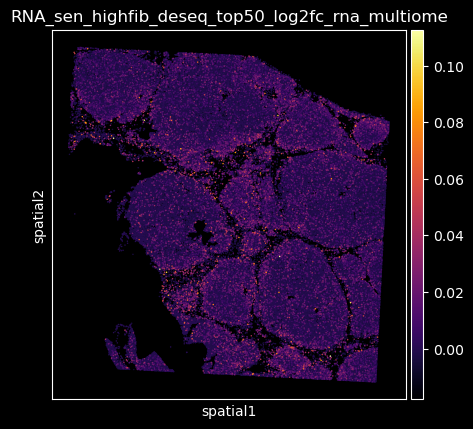

In [24]:
plt.style.use('dark_background')

sc.pl.spatial(
    adata_pred_filt_cropped, 
    color=score_name_fc, 
    color_map="inferno", 
    show=False, 
    size=4, 
    img_key=None,
)
plt.savefig(f"{odir}{score_name_fc}.pdf")

In [30]:
 adata_pred_filt_cropped

AnnData object with n_obs × n_vars = 178400 × 17910
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'RNA_sen_highfib_deseq_top50_log2fc_rna_multiome'
    uns: 'clusters', 'hvg', 'neighbors', 'pca', 'pred_cell_types_colors', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'

In [16]:
# Define your list of strings
hf_fc_list_50


odir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/RNA/clusterprofiler_kegg_react/top_deseq2_genes/'
#score_name = f"RNA_sen_highfib_deseq_top50_pval_rna_multiome"
# Specify the output file name
file_name = "RNA_sen_highfib_deseq_top50_log2fc_rna_multiome.txt"

whole_file_name = f"{odir}{file_name}"

# Write the list to the file, each item on a new line
with open(whole_file_name, "w") as f:
    for item in hf_fc_list_50:
        f.write(item + "\n")

print(f"List successfully written to {whole_file_name}")

List successfully written to /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/RNA/clusterprofiler_kegg_react/top_deseq2_genes/RNA_sen_highfib_deseq_top50_log2fc_rna_multiome.txt


[<Axes: title={'center': 'RNA_sen_highfib_deseq_top50_log2fc_rna_multiome'}, xlabel='spatial1', ylabel='spatial2'>]

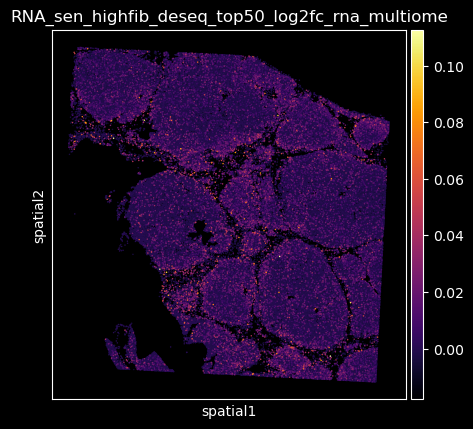

In [22]:
plt.style.use('dark_background')

sc.pl.spatial(
    adata_pred_filt_cropped, 
    color=score_name_fc, 
    color_map="inferno", 
    show=False, 
    size=4, 
    img_key=None,
)
#plt.savefig(f"{odir}{score_name_fc}.pdf")

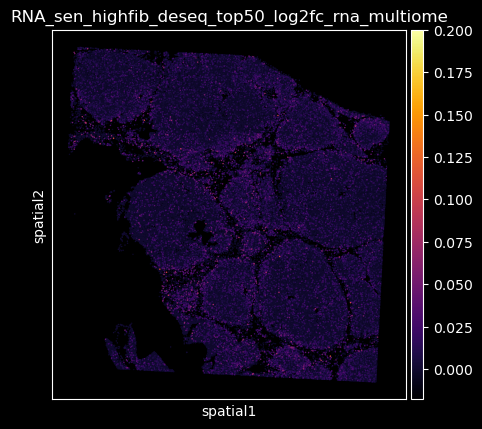

In [36]:
plt.style.use('dark_background')

sc.pl.spatial(
    adata_pred_filt_cropped, 
    color=score_name_fc, 
    color_map="inferno", 
    show=False, 
    size=4, 
    img_key=None,
   # vmin = 0.2,
    vmax = 0.2
)
plt.savefig(f"{odir}{score_name_fc}_scales.pdf")

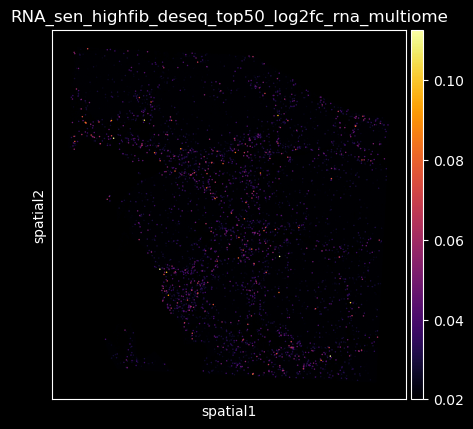

In [25]:
plt.style.use('dark_background')

sc.pl.spatial(
    adata_pred_filt_cropped, 
    color=score_name_fc, 
    color_map="inferno", 
    show=False, 
    size=4, 
    img_key=None,
    vmin = 0.02
)
plt.savefig(f"{odir}{score_name_fc}_test.pdf")

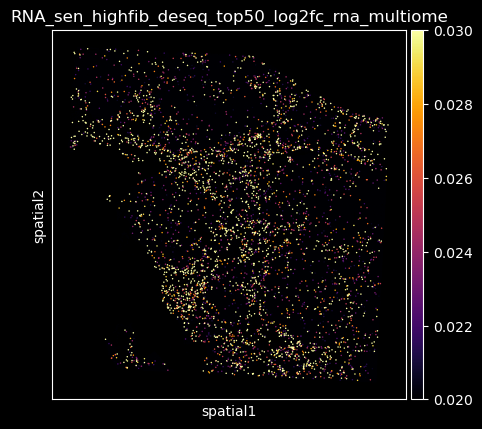

In [26]:
plt.style.use('dark_background')

sc.pl.spatial(
    adata_pred_filt_cropped, 
    color=score_name_fc, 
    color_map="inferno", 
    show=False, 
    size=4, 
    img_key=None,
    vmin = 0.02,
    vmax = 0.03
)
plt.savefig(f"{odir}{score_name_fc}_test_max_pt3.pdf")

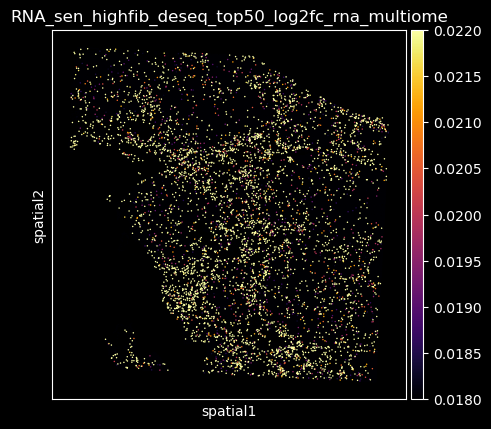

In [28]:
plt.style.use('dark_background')

sc.pl.spatial(
    adata_pred_filt_cropped, 
    color=score_name_fc, 
    color_map="inferno", 
    show=False, 
    size=4, 
    img_key=None,
    vmin = 0.02,
    vmax = 0.02
)
plt.savefig(f"{odir}{score_name_fc}_test_max_pt2.pdf")

In [29]:
1868/178400

0.01047085201793722

In [27]:
adata_pred_filt_cropped.obs[

AnnData object with n_obs × n_vars = 178400 × 17910
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'RNA_sen_highfib_deseq_top50_log2fc_rna_multiome'
    uns: 'clusters', 'hvg', 'neighbors', 'pca', 'pred_cell_types_colors', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'

In [25]:
hf_fc_list_50  # SPP1, COL4A1, CXCL8, ANXA1, BICC1, CXCL6, LGALS3, NCAM1, COL4A2, HK1, CD44, CDKN2A


['AL359313.1',
 'MSC-AS1',
 'KRT23',
 'SPP1',
 'CDH6',
 'COL4A1',
 'ITGB6',
 'NPSR1-AS1',
 'ANKRD1',
 'CXCL8',
 'MAP2',
 'AC092153.1',
 'LINC01435',
 'BICC1',
 'LINC02233',
 'HSPB8',
 'CA12',
 'ANXA1',
 'TESC',
 'CXCL6',
 'LGALS3',
 'STK39',
 'NCAM1',
 'ZNF385D-AS2',
 'LINC02477',
 'ZNF385D',
 'FGF13',
 'COL4A2',
 'TMEM156',
 'HK1',
 'AL807761.4',
 'LIPH',
 'TMEM178B',
 'FGF12',
 'BTBD11',
 'POF1B',
 'TSPAN15',
 'DLGAP1-AS3',
 'SLC25A24',
 'AKR1B1',
 'LINC02006',
 'CD44',
 'AKR1B10',
 'DAGLA',
 'CDKN2A',
 'IGF2BP2',
 'NRG2',
 'AP000851.1',
 'CD163L1',
 'CSGALNACT1']

In [26]:
adata_pred_filt_cropped

AnnData object with n_obs × n_vars = 178400 × 17910
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'RNA_sen_highfib_deseq_top50_pval_rna_multiome', 'RNA_sen_highfib_deseq_top50_log2fc_rna_multiome'
    uns: 'clusters', 'hvg', 'neighbors', 'pca', 'pred_cell_types_colors', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'

In [27]:
adata_pred_filt_cropped_filt = adata_pred_filt_cropped[adata_pred_filt_cropped.obs[score_name_fc] > 0.08].copy() #for heart used 25, liver 100

In [28]:
adata_pred_filt_cropped_filt

AnnData object with n_obs × n_vars = 19 × 17910
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'RNA_sen_highfib_deseq_top50_pval_rna_multiome', 'RNA_sen_highfib_deseq_top50_log2fc_rna_multiome'
    uns: 'clusters', 'hvg', 'neighbors', 'pca', 'pred_cell_types_colors', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'

In [29]:
adata_pred_filt_cropped_filt = adata_pred_filt_cropped[adata_pred_filt_cropped.obs[score_name_fc] > 0.05].copy() #for heart used 25, liver 100

In [30]:
adata_pred_filt_cropped_filt

AnnData object with n_obs × n_vars = 272 × 17910
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'RNA_sen_highfib_deseq_top50_pval_rna_multiome', 'RNA_sen_highfib_deseq_top50_log2fc_rna_multiome'
    uns: 'clusters', 'hvg', 'neighbors', 'pca', 'pred_cell_types_colors', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'

In [31]:
adata_pred_filt_cropped_filt = adata_pred_filt_cropped[adata_pred_filt_cropped.obs[score_name_fc] > 0.02].copy() #for heart used 25, liver 100

In [32]:
adata_pred_filt_cropped_filt

AnnData object with n_obs × n_vars = 4833 × 17910
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'RNA_sen_highfib_deseq_top50_pval_rna_multiome', 'RNA_sen_highfib_deseq_top50_log2fc_rna_multiome'
    uns: 'clusters', 'hvg', 'neighbors', 'pca', 'pred_cell_types_colors', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'

In [33]:
4833 / 178400

0.027090807174887894

In [34]:
# Create a new metadata column with labels
adata_pred_filt_cropped.obs["pt02_score"] = np.where(
    adata_pred_filt_cropped.obs[score_name_fc] > 0.02, "High_Score", "Low_Score"
)

# Check the assignment
adata_pred_filt_cropped.obs["pt02_score"].value_counts()

pt02_score
Low_Score     173567
High_Score      4833
Name: count, dtype: int64

In [35]:
# Define your color dictionary
fc_colors = {
    "High_Score": "#FF0000",  # Red for high fold change
    "Low_Score": "#0000FF"   # Blue for low fold change
}


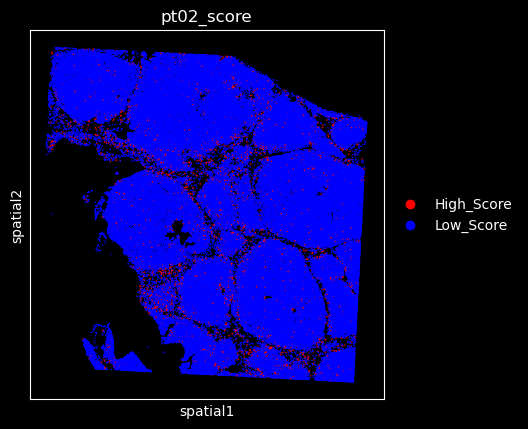

In [36]:
plt.style.use('dark_background')

sc.pl.spatial(
    adata_pred_filt_cropped, 
    color='pt02_score', 
    color_map="inferno", 
    palette = fc_colors,
    show=False,
    size=4, 
    img_key=None,
)
plt.savefig(f"{odir}all_pt02_score.pdf")

/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


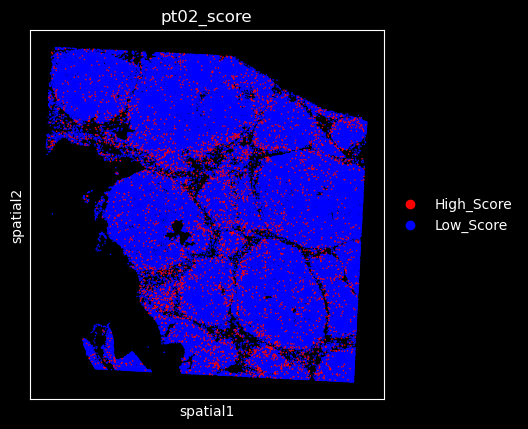

In [37]:
plt.style.use('dark_background')

sc.pl.spatial(
    adata_pred_filt_cropped[adata_pred_filt_cropped.obs.sort_values("pt02_score", ascending = False).index], 
    color='pt02_score', 
    color_map="inferno", 
    palette = fc_colors,
    show=False, 
    size=4, 
    img_key=None,
)
plt.savefig(f"{odir}all_pt02_score_top.pdf")

In [141]:
# Plot with the reordered data
sc.pl.spatial(
    adata[adata.obs.sort_values("fold_change_label").index],  # Reorder so High_Score is last
    color="fold_change_label",
    palette={"High_Score": "#FF0000", "Low_Score": "#0000FF"},
    size=4,
    img_key=None
)

NameError: name 'adata' is not defined

In [ ]:
what are the labels, zone1, zone2, zone3, sen, high fc

In [38]:
adata_pred_filt_cropped_pt02 = adata_pred_filt_cropped[adata_pred_filt_cropped.obs["pt02_score"].isin(['High_Score'])]
                                                                                                    

In [39]:
adata_pred_filt_cropped_pt02

View of AnnData object with n_obs × n_vars = 4833 × 17910
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'RNA_sen_highfib_deseq_top50_pval_rna_multiome', 'RNA_sen_highfib_deseq_top50_log2fc_rna_multiome', 'pt02_score'
    uns: 'clusters', 'hvg', 'neighbors', 'pca', 'pred_cell_types_colors', 'spatial', 'umap', 'pt02_score_colors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'

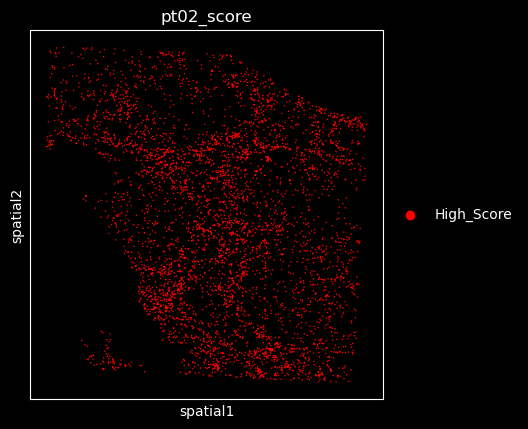

In [40]:
plt.style.use('dark_background')

sc.pl.spatial(
    adata_pred_filt_cropped_pt02, 
    color='pt02_score', 
    color_map="inferno", 
    show=False, 
    size=4, 
    img_key=None,
)
plt.savefig(f"{odir}pt02_score.pdf")

In [41]:
adata_pred_filt_cropped_filt = adata_pred_filt_cropped[adata_pred_filt_cropped.obs[score_name_fc] > 0.01].copy() #for heart used 25, liver 100

In [42]:
adata_pred_filt_cropped_filt

AnnData object with n_obs × n_vars = 13422 × 17910
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'RNA_sen_highfib_deseq_top50_pval_rna_multiome', 'RNA_sen_highfib_deseq_top50_log2fc_rna_multiome', 'pt02_score'
    uns: 'clusters', 'hvg', 'neighbors', 'pca', 'pred_cell_types_colors', 'spatial', 'umap', 'pt02_score_colors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'

In [147]:
13422 / 178400

0.07523542600896861

In [43]:
adata_pred_filt_cropped.obs["pt01_score"] = adata_pred_filt_cropped[adata_pred_filt_cropped.obs[score_name_fc] > 0.01].copy() #for heart used 25, liver 100

In [44]:
del adata_pred_filt_cropped.obs["pt01_score"]

In [45]:
#adata_pred_filt_cropped.obs['pt01_score'].value_counts()

In [46]:
# Create a new metadata column with labels
adata_pred_filt_cropped.obs["pt01_score"] = np.where(
    adata_pred_filt_cropped.obs[score_name_fc] > 0.01, "High_Score", "Low_Score"
)

# Check the assignment
adata_pred_filt_cropped.obs["pt01_score"].value_counts()

pt01_score
Low_Score     164978
High_Score     13422
Name: count, dtype: int64

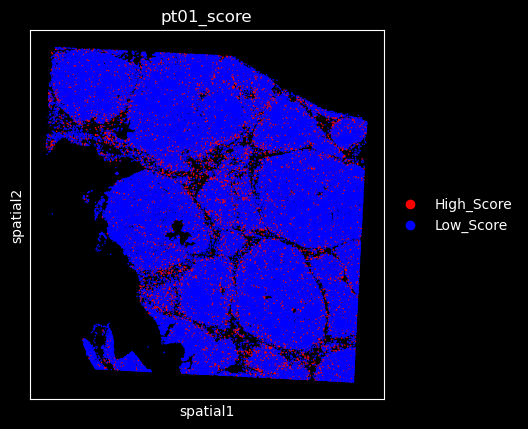

In [47]:
plt.style.use('dark_background')

sc.pl.spatial(
    adata_pred_filt_cropped, 
    color='pt01_score', 
    color_map="inferno", 
    palette = fc_colors,
    show=False,
    size=4, 
    img_key=None,
)
plt.savefig(f"{odir}all_pt01_score.pdf")

/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


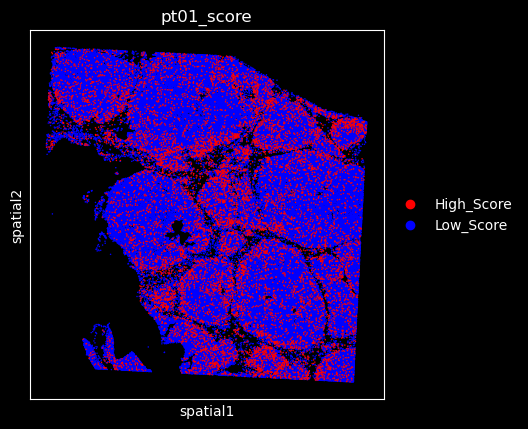

In [48]:
plt.style.use('dark_background')

sc.pl.spatial(
    adata_pred_filt_cropped[adata_pred_filt_cropped.obs.sort_values("pt01_score", ascending = False).index], 
    color='pt01_score', 
    color_map="inferno", 
    palette = fc_colors,
    show=False, 
    size=4, 
    img_key=None,
)
plt.savefig(f"{odir}all_pt01_score_top.pdf")

In [49]:
adata_pred_filt_cropped_pt01 = adata_pred_filt_cropped[adata_pred_filt_cropped.obs['pt01_score'].isin(['High_Score'])]

In [50]:
adata_pred_filt_cropped_pt01

View of AnnData object with n_obs × n_vars = 13422 × 17910
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'RNA_sen_highfib_deseq_top50_pval_rna_multiome', 'RNA_sen_highfib_deseq_top50_log2fc_rna_multiome', 'pt02_score', 'pt01_score'
    uns: 'clusters', 'hvg', 'neighbors', 'pca', 'pred_cell_types_colors', 'spatial', 'umap', 'pt02_score_colors', 'pt01_score_colors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'

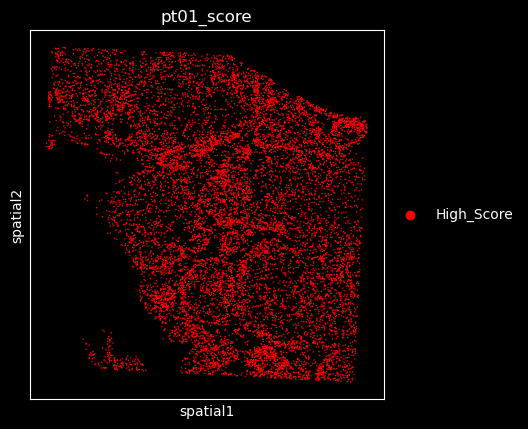

In [51]:
plt.style.use('dark_background')

sc.pl.spatial(
    adata_pred_filt_cropped_pt01, 
    color='pt01_score', 
    color_map="inferno", 
    show=False, 
    size=4, 
    img_key=None,
)
plt.savefig(f"{odir}pt01_score.pdf")

In [52]:
neon_rainbow_colors_broad_sen =  {
    'Hepatocytes.Zone1': '#FF007F',    # Neon pink
    'Hepatocytes.Zone2': '#0000FF',           # Neon blue
    'Hepatocytes.Zone3': '#FFFA00',              # Neon yellow
    'Hepatocytes.Senescent': '#00FF00',  # Neon green
    'Hepatocytes.Stress': '#00FFFF'           # Neon cyan
         # Neon hot pink
}

[<Axes: title={'center': 'celltype_proj'}, xlabel='spatial1', ylabel='spatial2'>]

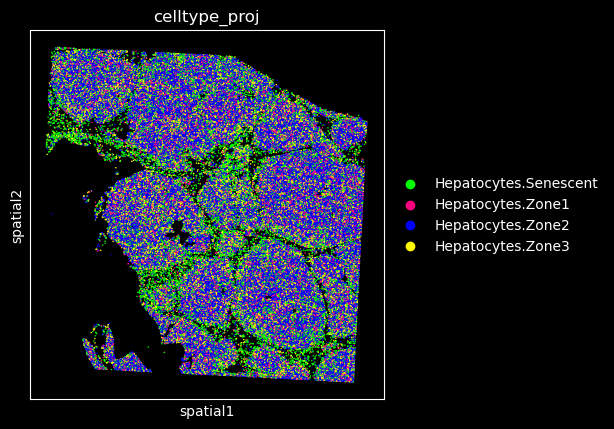

In [53]:
plt.style.use('dark_background')

sc.pl.spatial(
    adata_pred_filt_cropped, 
    color='celltype_proj', 
    color_map="inferno", 
    show=False, 
    size=4, 
    palette=neon_rainbow_colors_broad_sen,  # Customize colors
    img_key=None,
)

/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


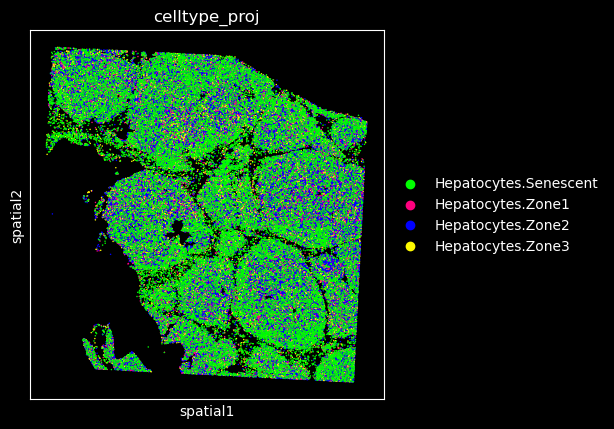

In [54]:
# Define the target cell type you want to appear on top
target_celltype = "Hepatocytes.Senescent"

# Sort so that the target cell type is last
adata_sorted = adata_pred_filt_cropped[
    adata_pred_filt_cropped.obs.sort_values(by="celltype_proj", key=lambda x: x != target_celltype, ascending =False).index
]

neon_rainbow_colors_broad_sen =  {
    'Hepatocytes.Zone1': '#FF007F',    # Neon pink
    'Hepatocytes.Zone2': '#0000FF',           # Neon blue
    'Hepatocytes.Zone3': '#FFFA00',              # Neon yellow
    'Hepatocytes.Senescent': '#00FF00',  # Neon green
    'Hepatocytes.Stress': '#00FFFF'           # Neon cyan
         # Neon hot pink
}
# Plot the reordered data
sc.pl.spatial(
    adata_sorted,
    color="celltype_proj",
    palette=neon_rainbow_colors_broad_sen,  # Customize colors
    size=4,
    img_key=None
)

/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


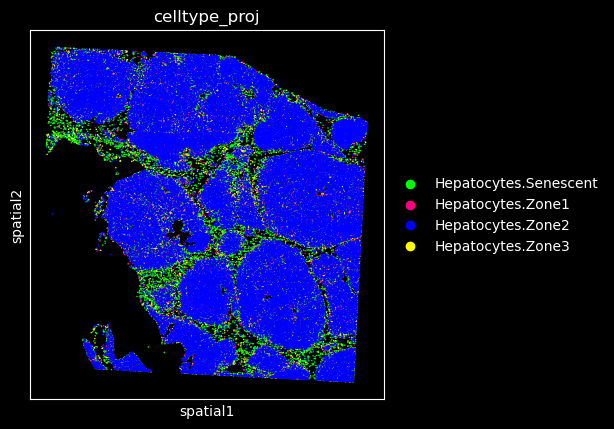

In [55]:
# Define the target cell type you want to appear on top
target_celltype = "Hepatocytes.Zone2"

# Sort so that the target cell type is last
adata_sorted = adata_pred_filt_cropped[
    adata_pred_filt_cropped.obs.sort_values(by="celltype_proj", key=lambda x: x != target_celltype, ascending =False).index
]

neon_rainbow_colors_broad_sen =  {
    'Hepatocytes.Zone1': '#FF007F',    # Neon pink
    'Hepatocytes.Zone2': '#0000FF',           # Neon blue
    'Hepatocytes.Zone3': '#FFFA00',              # Neon yellow
    'Hepatocytes.Senescent': '#00FF00',  # Neon green
    'Hepatocytes.Stress': '#00FFFF'           # Neon cyan
         # Neon hot pink
}
# Plot the reordered data
sc.pl.spatial(
    adata_sorted,
    color="celltype_proj",
    palette=neon_rainbow_colors_broad_sen,  # Customize colors
    size=4,
    img_key=None
)

/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


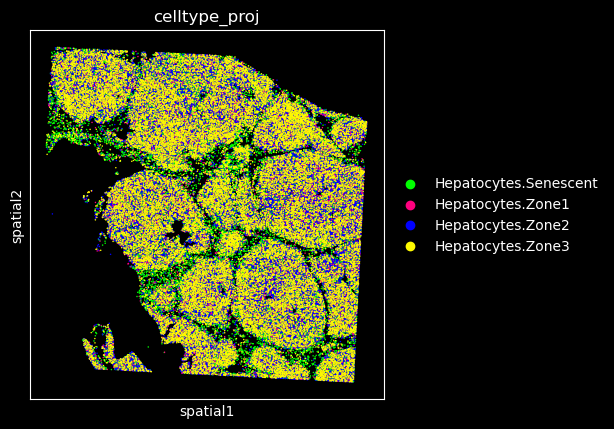

In [56]:
# Define the target cell type you want to appear on top
target_celltype = "Hepatocytes.Zone3"

# Sort so that the target cell type is last
adata_sorted = adata_pred_filt_cropped[
    adata_pred_filt_cropped.obs.sort_values(by="celltype_proj", key=lambda x: x != target_celltype, ascending =False).index
]

neon_rainbow_colors_broad_sen =  {
    'Hepatocytes.Zone1': '#FF007F',    # Neon pink
    'Hepatocytes.Zone2': '#0000FF',           # Neon blue
    'Hepatocytes.Zone3': '#FFFA00',              # Neon yellow
    'Hepatocytes.Senescent': '#00FF00',  # Neon green
    'Hepatocytes.Stress': '#00FFFF'           # Neon cyan
         # Neon hot pink
}
# Plot the reordered data
sc.pl.spatial(
    adata_sorted,
    color="celltype_proj",
    palette=neon_rainbow_colors_broad_sen,  # Customize colors
    size=4,
    img_key=None
)

In [57]:
adata_pred_filt_cropped.obs["pt01_score"].value_counts()

pt01_score
Low_Score     164978
High_Score     13422
Name: count, dtype: int64

In [58]:
adata_pred_filt_cropped.obs["pt02_score"].value_counts()

pt02_score
Low_Score     173567
High_Score      4833
Name: count, dtype: int64

In [163]:
os.makedirs('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/neighborhood_analysis/high_score_sen_cells/')

In [164]:
odir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/neighborhood_analysis/high_score_sen_cells/'

In [ ]:
# within the senescent cells make the ones that have high scores with the high score label

In [59]:
adata_pred_filt_cropped.obs['celltype_proj'].value_counts()

celltype_proj
Hepatocytes.Zone2        86149
Hepatocytes.Zone3        32992
Hepatocytes.Senescent    32355
Hepatocytes.Zone1        26904
Name: count, dtype: int64

In [ ]:
adata_pred_filt_cropped

In [73]:
target_cells = ['Hepatocytes.Senescent']

adata_pred_filt_cropped.obs['celltype_proj_heps_pt01'] = adata_pred_filt_cropped.obs.apply(
    lambda row: 'Hepatocytes.Senescent.High' if row['pt01_score'] == 'High_Score' and row['celltype_proj'] in target_cells else row['celltype_proj'], axis=1
)

In [74]:
adata_pred_filt_cropped.obs['celltype_proj_heps_pt01'].value_counts()

celltype_proj_heps_pt01
Hepatocytes.Zone2             86149
Hepatocytes.Zone3             32992
Hepatocytes.Senescent         28161
Hepatocytes.Zone1             26904
Hepatocytes.Senescent.High     4194
Name: count, dtype: int64

In [75]:
target_cells = ['Hepatocytes.Senescent']

adata_pred_filt_cropped.obs['celltype_proj_heps_pt02'] = adata_pred_filt_cropped.obs.apply(
    lambda row: 'Hepatocytes.Senescent.High' if row['pt02_score'] == 'High_Score' and row['celltype_proj'] in target_cells else row['celltype_proj'], axis=1
)

In [76]:
adata_pred_filt_cropped.obs['celltype_proj_heps_pt02'].value_counts()

celltype_proj_heps_pt02
Hepatocytes.Zone2             86149
Hepatocytes.Zone3             32992
Hepatocytes.Senescent         30487
Hepatocytes.Zone1             26904
Hepatocytes.Senescent.High     1868
Name: count, dtype: int64

In [86]:
adata_pred_filt_cropped

AnnData object with n_obs × n_vars = 178400 × 17910
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'RNA_sen_highfib_deseq_top50_pval_rna_multiome', 'RNA_sen_highfib_deseq_top50_log2fc_rna_multiome', 'pt02_score', 'pt01_score', 'celltype_proj_heps_pt01', 'celltype_proj_heps_pt02'
    uns: 'clusters', 'hvg', 'neighbors', 'pca', 'pred_cell_types_colors', 'spatial', 'umap', 'pt02_score_colors', 'pt01_score_colors', 'celltype_proj_colors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'

In [90]:
adata_pred_filt_cropped

AnnData object with n_obs × n_vars = 178400 × 17910
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'RNA_sen_highfib_deseq_top50_pval_rna_multiome', 'RNA_sen_highfib_deseq_top50_log2fc_rna_multiome', 'pt02_score', 'pt01_score', 'celltype_proj_heps_pt01', 'celltype_proj_heps_pt02'
    uns: 'clusters', 'hvg', 'neighbors', 'pca', 'pred_cell_types_colors', 'spatial', 'umap', 'pt02_score_colors', 'pt01_score_colors', 'celltype_proj_colors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'

In [97]:
odir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/neighborhood_analysis/high_score_sen_cells/'

In [98]:
adata_pred_filt_cropped.write_h5ad(f"{odir}adata_heps_score_sencells_labels.h5ad")

In [93]:
adata_pred_filt_cropped

AnnData object with n_obs × n_vars = 178400 × 17910
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'RNA_sen_highfib_deseq_top50_pval_rna_multiome', 'RNA_sen_highfib_deseq_top50_log2fc_rna_multiome', 'pt02_score', 'pt01_score', 'celltype_proj_heps_pt01', 'celltype_proj_heps_pt02'
    uns: 'clusters', 'hvg', 'neighbors', 'pca', 'pred_cell_types_colors', 'spatial', 'umap', 'pt02_score_colors', 'pt01_score_colors', 'celltype_proj_colors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'

In [96]:
odir

'/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/RNA/clusterprofiler_kegg_react/top_deseq2_genes/'

In [99]:
test = sc.read_h5ad('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/neighborhood_analysis/high_score_sen_cells/adata_heps_score_sencells_labels.h5ad')

In [ ]:
# from paper very original
neon_rainbow_colors_broad = {
        'Hepatocytes': '#FF007F',    # Neon pink #maroon is '#800000'
        'Myeloid': '#0000FF',           # Neon blue
        'T_NK': '#FFFA00',              # Neon yellow
        'Cholangiocyte': '#00FF00',  # Neon green
        'HSC': '#00FFFF',            # Neon cyan
        'Mast': '#FF1900',        # Neon red
        'Endothelial': '#8A2BE2',    # Neon purple
        'Schwann': '#FF1493',        # Neon deep pink
        'NK': '#FFFDBB',             # lighter yellow
        'B': '#FF8800'               # Neon hot pink
    }

In [ ]:
neon_rainbow_colors_broad_sen =  {
    'Hepatocytes.Zone1': '#FF007F',    # Neon pink
    'Hepatocytes.Zone2': '#0000FF',           # Neon blue
    'Hepatocytes.Zone3': '#FFFA00',              # Neon yellow
    'Hepatocytes.Senescent': '#00FF00',  # Neon green
    'Hepatocytes.Stress': '#00FFFF'           # Neon cyan
         # Neon hot pink
}

In [104]:
neon_rainbow_colors_broad = {
        #'Hepatocytes': '#FF007F',    # Neon pink #maroon is '#800000'
        'Myeloid': '#0000FF',           # Neon blue
        'T_NK': '#FFFA00',              # Neon yellow
        'Cholangiocyte': '#00FF00',  # Neon green
        'HSC': '#00FFFF',            # Neon cyan
        #'Mast': '#FF1900',        # Neon red
        'Endothelial': '#8A2BE2',    # Neon purple
       # 'Schwann': '#FF1493',        # Neon deep pink
        'NK': '#FFFDBB',             # lighter yellow
        'B': '#FF8800',               # Neon hot pink
       'Hepatocytes.Zone1': '#FF007F',    # Neon pink
        'Hepatocytes.Zone2':  '#FF6600', # neon orange '#0000FF',           # Neon blue
        'Hepatocytes.Zone3': '#99FF00', # lime green #99FF00             # Neon yellow
        'Hepatocytes.Senescent.High': '#9B00FF',  # Neon green
        'Hepatocytes.Senescent': '#00FF00',  # Neon green
        'Hepatocytes.Stress': '#00FFFF'       
    }

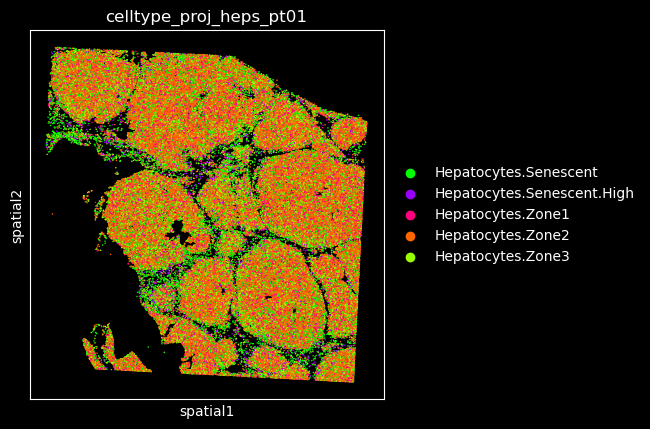

In [105]:
sc.pl.spatial(
    test,
    color="celltype_proj_heps_pt01",
    palette=neon_rainbow_colors_broad,  # Customize colors
    size=4,
    img_key=None
)

In [ ]:
odir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/RNA/clusterprofiler_kegg_react/top_deseq2_genes/'

In [100]:
test

AnnData object with n_obs × n_vars = 178400 × 17910
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'RNA_sen_highfib_deseq_top50_pval_rna_multiome', 'RNA_sen_highfib_deseq_top50_log2fc_rna_multiome', 'pt02_score', 'pt01_score', 'celltype_proj_heps_pt01', 'celltype_proj_heps_pt02'
    uns: 'celltype_proj_colors', 'clusters', 'hvg', 'neighbors', 'pca', 'pred_cell_types_colors', 'pt01_score_colors', 'pt02_score_colors', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'

In [102]:
test.obs['celltype_proj_heps_pt01'].value_counts()

celltype_proj_heps_pt01
Hepatocytes.Zone2             86149
Hepatocytes.Zone3             32992
Hepatocytes.Senescent         28161
Hepatocytes.Zone1             26904
Hepatocytes.Senescent.High     4194
Name: count, dtype: int64

In [101]:
test.obs['celltype_proj_heps_pt02'].value_counts()

celltype_proj_heps_pt02
Hepatocytes.Zone2             86149
Hepatocytes.Zone3             32992
Hepatocytes.Senescent         30487
Hepatocytes.Zone1             26904
Hepatocytes.Senescent.High     1868
Name: count, dtype: int64

In [168]:
test.obs["pt01_score"].value_counts()

pt01_score
Low_Score     164978
High_Score     13422
Name: count, dtype: int64

In [169]:
test.obs["pt02_score"].value_counts()

pt02_score
Low_Score     173567
High_Score      4833
Name: count, dtype: int64

In [103]:
1868/178000

0.01049438202247191

In [ ]:
# pt01

In [106]:
adata = sc.read_h5ad('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tangram_scores_dist2/HL20221019_broad_no_mast_filt/adata_0.5_tangram_filt.h5ad')

In [107]:
adata_heps = sc.read_h5ad('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/neighborhood_analysis/high_score_sen_cells/adata_heps_score_sencells_labels.h5ad')

In [108]:
full_adata = adata.copy()

In [109]:
import scanpy as sc
import pandas as pd


# Step 1: Create a dictionary mapping cell indices to their 'celltype_proj_heps_pt01' labels
hepatocyte_mapping = adata_heps.obs['celltype_proj_heps_pt01'].to_dict()

# Step 2: Map 'celltype_proj_heps_pt01' back into full_adata
full_adata.obs['celltype_proj_heps_pt01'] = full_adata.obs.index.map(hepatocyte_mapping)

# Step 3: Convert 'celltype_proj_heps_pt01' and 'pred_cell_types' to strings (if not already)
full_adata.obs['celltype_proj_heps_pt01'] = full_adata.obs['celltype_proj_heps_pt01'].astype(str)
full_adata.obs['pred_cell_types'] = full_adata.obs['pred_cell_types'].astype(str)

# Step 4: Fill NaNs in 'celltype_proj_heps_pt01' using 'pred_cell_types'
full_adata.obs['celltype_proj_heps_pt01'].fillna(full_adata.obs['pred_cell_types'], inplace=True)

# Step 5: Convert back to categorical to optimize memory usage
full_adata.obs['celltype_proj_heps_pt01'] = full_adata.obs['celltype_proj_heps_pt01'].astype("category")

# Check results
print(full_adata.obs[['pred_cell_types', 'celltype_proj_heps_pt01']].head())


       pred_cell_types celltype_proj_heps_pt01
505995     Hepatocytes       Hepatocytes.Zone2
505996     Hepatocytes       Hepatocytes.Zone3
505997               B                     nan
506002     Hepatocytes       Hepatocytes.Zone2
506003     Endothelial                     nan


/tmp/ipykernel_1387648/1885351014.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  full_adata.obs['celltype_proj_heps_pt01'].fillna(full_adata.obs['pred_cell_types'], inplace=True)


In [110]:
# Create a mapping dictionary from hepatocyte object
hepatocyte_mapping = adata_heps.obs['celltype_proj_heps_pt01'].to_dict()

# Map 'celltype_proj_heps_pt01' values back to the full AnnData object
full_adata.obs['celltype_proj_heps_pt01'] = full_adata.obs.index.map(hepatocyte_mapping)

full_adata.obs['celltype_proj_heps_pt01'] = full_adata.obs['celltype_proj_heps_pt01'].fillna(full_adata.obs['pred_cell_types'])

# Check if mapping was successful
print(full_adata.obs[['pred_cell_types', 'celltype_proj_heps_pt01']].head())



       pred_cell_types celltype_proj_heps_pt01
505995     Hepatocytes       Hepatocytes.Zone2
505996     Hepatocytes       Hepatocytes.Zone3
505997               B                       B
506002     Hepatocytes       Hepatocytes.Zone2
506003     Endothelial             Endothelial


In [111]:
# Step 5: Convert back to categorical to optimize memory usage
full_adata.obs['celltype_proj_heps_pt01'] = full_adata.obs['celltype_proj_heps_pt01'].astype("category")


In [112]:
full_adata.obs['celltype_proj_heps_pt01'].value_counts()

celltype_proj_heps_pt01
Hepatocytes.Zone2             86149
Hepatocytes.Zone3             32992
Hepatocytes.Senescent         28161
Hepatocytes.Zone1             26904
Myeloid                       22435
Endothelial                   21097
HSC                           17476
Cholangiocyte                 10859
B                             10049
T_NK                           9995
Hepatocytes.Senescent.High     4194
Name: count, dtype: int64

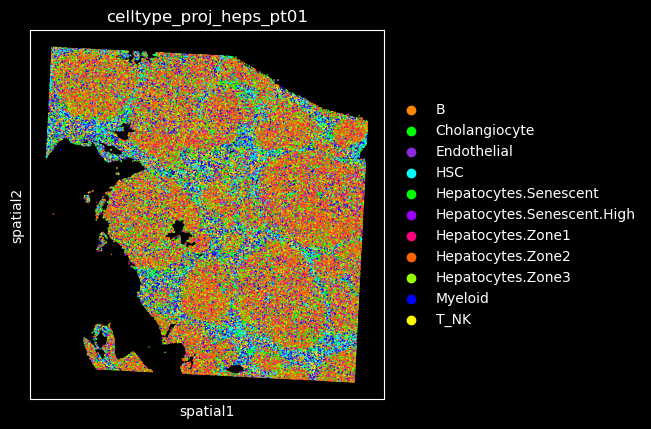

In [113]:
sc.pl.spatial(
    full_adata,
    color="celltype_proj_heps_pt01",
    palette=neon_rainbow_colors_broad,  # Customize colors
    size=4,
    img_key=None
)

In [129]:
neon_rainbow_colors_broad_grey = {
        #'Hepatocytes': '#FF007F',    # Neon pink #maroon is '#800000'
        'Myeloid': '#0000FF',           # Neon blue
        'T_NK': '#FFFA00',              # Neon yellow
        'Cholangiocyte': '#00FF00',  # Neon green
        'HSC': '#00FFFF',            # Neon cyan
        #'Mast': '#FF1900',        # Neon red
        'Endothelial': '#8A2BE2',    # Neon purple
       # 'Schwann': '#FF1493',        # Neon deep pink
        'NK': '#FFFDBB',             # lighter yellow
        'B': '#FF8800',               # Neon hot pink
       'Hepatocytes.Zone1': '#D3D3D3',    # Neon pink
        'Hepatocytes.Zone2':  '#D3D3D3', # neon orange '#0000FF',           # Neon blue
        'Hepatocytes.Zone3': '#D3D3D3', # lime green #99FF00             # Neon yellow
        'Hepatocytes.Senescent.High': '#FF1900',  # Neon red
        'Hepatocytes.Senescent': '#00FF00',  # Neon green
        'Hepatocytes.Stress': '#00FFFF'       
    }

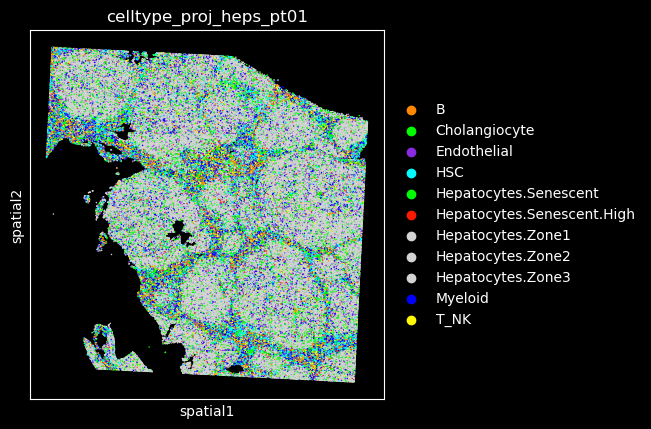

In [130]:
sc.pl.spatial(
    full_adata,
    color="celltype_proj_heps_pt01",
    palette=neon_rainbow_colors_broad_grey,  # Customize colors
    size=4,
    img_key=None
)

In [150]:
adata_heps_sen_other_ct  = full_adata[full_adata.obs['celltype_proj_heps_pt01'].isin(['B', 'Cholangiocyte',
                                                                          'Endothelial','HSC', 'Hepatocytes.Senescent',
                                                                          'Hepatocytes.Senescent.High', 'Myeloid', 'T_NK'])]
    

In [151]:
adata_heps_sen_other_ct 

View of AnnData object with n_obs × n_vars = 124266 × 17931
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'celltype_proj_heps_pt01'
    uns: 'celltype_proj_colors', 'clusters', 'hvg', 'neighbors', 'pca', 'spatial', 'umap', 'celltype_proj_heps_pt01_colors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'

In [145]:
odir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/neighborhood_analysis/high_score_sen_cells/'

/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


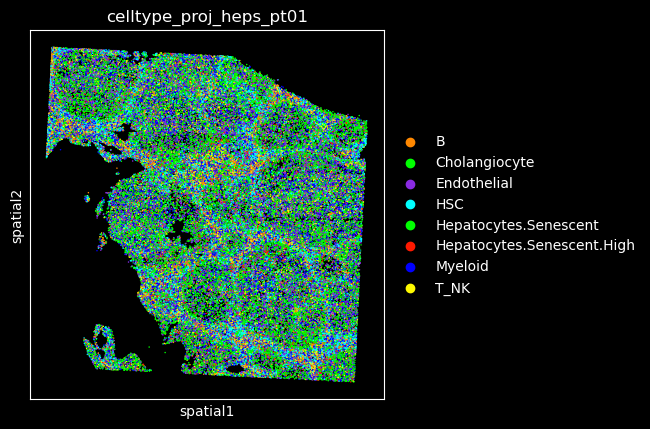

In [152]:
sc.pl.spatial(
    adata_heps_sen_other_ct,
    color="celltype_proj_heps_pt01",
    palette=neon_rainbow_colors_broad_grey,  # Customize colors
    size=4,
    img_key=None,
    show = False #in order to write out to pdf
    
)
plt.savefig(f"{odir}sen_cells_other_ct.pdf")

/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


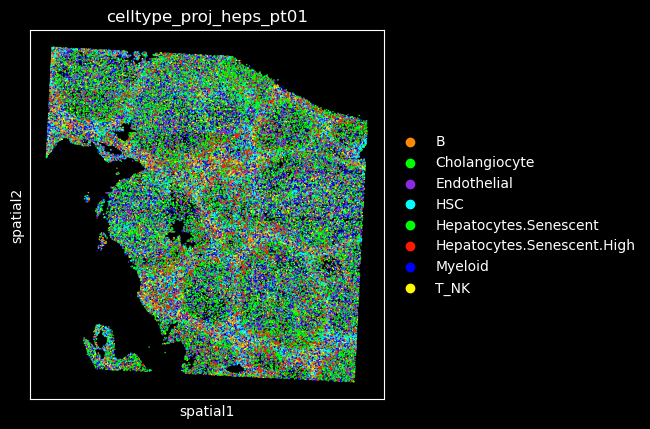

In [153]:
# Define the target cell type you want to appear on top
target_celltype = "Hepatocytes.Senescent.High"

# Sort so that the target cell type is last
adata_sorted = adata_heps_sen_other_ct[
   adata_heps_sen_other_ct.obs.sort_values(by="celltype_proj_heps_pt01", key=lambda x: x != target_celltype, ascending =False).index
]

# Plot the reordered data
sc.pl.spatial(
    adata_sorted,
    color="celltype_proj_heps_pt01",
    palette=neon_rainbow_colors_broad_grey,  # Customize colors
    size=4,
    img_key=None,
    show = False
)
plt.savefig(f"{odir}sen_cells_other_ct_top.pdf")

In [147]:
adata_heps_sen_other_ct  = full_adata[full_adata.obs['celltype_proj_heps_pt01'].isin(['B', 'Cholangiocyte',
                                                                          'Endothelial','HSC',
                                                                          'Hepatocytes.Senescent.High', 'Myeloid', 'T_NK'])]
    

/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


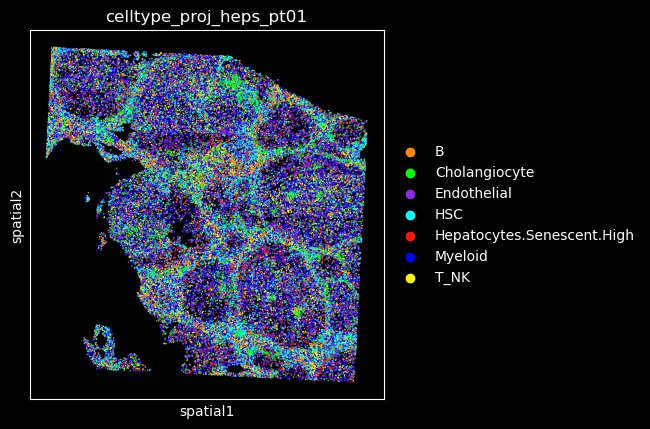

In [148]:
sc.pl.spatial(
    adata_heps_sen_other_ct,
    color="celltype_proj_heps_pt01",
    palette=neon_rainbow_colors_broad_grey,  # Customize colors
    size=4,
    img_key=None,
    show = False
)
plt.savefig(f"{odir}sen_high_cells_other_ct.pdf")

In [ ]:
# put high on top

/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


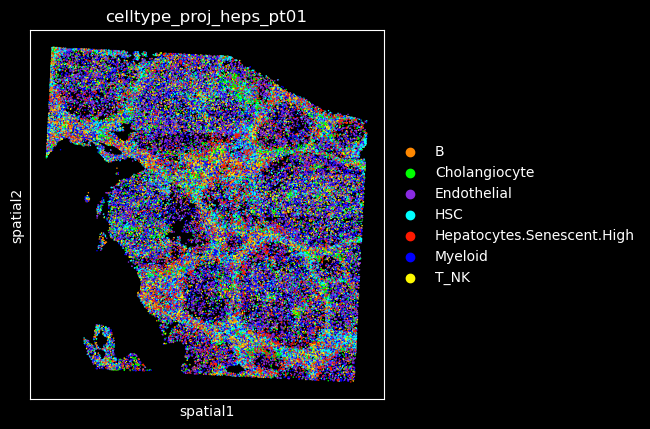

In [149]:
# Define the target cell type you want to appear on top
target_celltype = "Hepatocytes.Senescent.High"

# Sort so that the target cell type is last
adata_sorted = adata_heps_sen_other_ct[
   adata_heps_sen_other_ct.obs.sort_values(by="celltype_proj_heps_pt01", key=lambda x: x != target_celltype, ascending =False).index
]

# Plot the reordered data
sc.pl.spatial(
    adata_sorted,
    color="celltype_proj_heps_pt01",
    palette=neon_rainbow_colors_broad_grey,  # Customize colors
    size=4,
    img_key=None,
    show = False
)
plt.savefig(f"{odir}sen_high_cells_other_ct_top.pdf")

In [ ]:
#### 0.02 cells

In [163]:
import scanpy as sc
import pandas as pd


# Step 1: Create a dictionary mapping cell indices to their 'celltype_proj_heps_pt01' labels
hepatocyte_mapping = adata_heps.obs['celltype_proj_heps_pt02'].to_dict()

# Step 2: Map 'celltype_proj_heps_pt01' back into full_adata
full_adata.obs['celltype_proj_heps_pt02'] = full_adata.obs.index.map(hepatocyte_mapping)

# Step 3: Convert 'celltype_proj_heps_pt02' and 'pred_cell_types' to strings (if not already)
full_adata.obs['celltype_proj_heps_pt02'] = full_adata.obs['celltype_proj_heps_pt02'].astype(str)
full_adata.obs['pred_cell_types'] = full_adata.obs['pred_cell_types'].astype(str)

# Step 4: Fill NaNs in 'celltype_proj_heps_pt02' using 'pred_cell_types'
full_adata.obs['celltype_proj_heps_pt02'].fillna(full_adata.obs['pred_cell_types'], inplace=True)

# Step 5: Convert back to categorical to optimize memory usage
full_adata.obs['celltype_proj_heps_pt02'] = full_adata.obs['celltype_proj_heps_pt02'].astype("category")

# Check results
print(full_adata.obs[['pred_cell_types', 'celltype_proj_heps_pt02']].head())


       pred_cell_types celltype_proj_heps_pt02
505995     Hepatocytes       Hepatocytes.Zone2
505996     Hepatocytes       Hepatocytes.Zone3
505997               B                     nan
506002     Hepatocytes       Hepatocytes.Zone2
506003     Endothelial                     nan


/tmp/ipykernel_1387648/658412410.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  full_adata.obs['celltype_proj_heps_pt02'].fillna(full_adata.obs['pred_cell_types'], inplace=True)


In [164]:
# Create a mapping dictionary from hepatocyte object
hepatocyte_mapping = adata_heps.obs['celltype_proj_heps_pt02'].to_dict()

# Map 'celltype_proj_heps_pt02' values back to the full AnnData object
full_adata.obs['celltype_proj_heps_pt02'] = full_adata.obs.index.map(hepatocyte_mapping)

full_adata.obs['celltype_proj_heps_pt02'] = full_adata.obs['celltype_proj_heps_pt02'].fillna(full_adata.obs['pred_cell_types'])

# Check if mapping was successful
print(full_adata.obs[['pred_cell_types', 'celltype_proj_heps_pt02']].head())



       pred_cell_types celltype_proj_heps_pt02
505995     Hepatocytes       Hepatocytes.Zone2
505996     Hepatocytes       Hepatocytes.Zone3
505997               B                       B
506002     Hepatocytes       Hepatocytes.Zone2
506003     Endothelial             Endothelial


In [165]:
# Step 5: Convert back to categorical to optimize memory usage
full_adata.obs['celltype_proj_heps_pt02'] = full_adata.obs['celltype_proj_heps_pt02'].astype("category")


In [166]:
adata_heps_sen_other_ct  = full_adata[full_adata.obs['celltype_proj_heps_pt02'].isin(['B', 'Cholangiocyte',
                                                                          'Endothelial','HSC', 'Hepatocytes.Senescent',
                                                                          'Hepatocytes.Senescent.High', 'Myeloid', 'T_NK'])]
    

/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


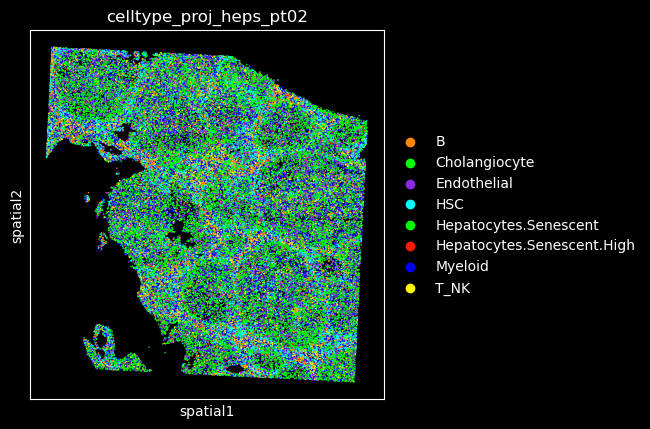

In [167]:
sc.pl.spatial(
    adata_heps_sen_other_ct,
    color="celltype_proj_heps_pt02",
    palette=neon_rainbow_colors_broad_grey,  # Customize colors
    size=4,
    img_key=None,
    show = False #in order to write out to pdf
    
)
plt.savefig(f"{odir}pt02_sen_cells_other_ct.pdf")

/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


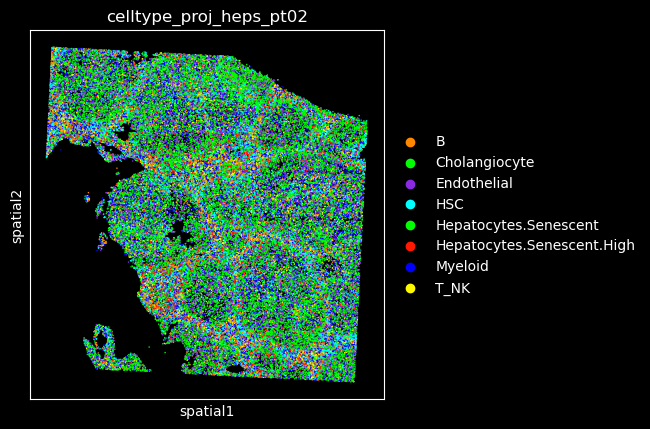

In [168]:
# Define the target cell type you want to appear on top
target_celltype = "Hepatocytes.Senescent.High"

# Sort so that the target cell type is last
adata_sorted = adata_heps_sen_other_ct[
   adata_heps_sen_other_ct.obs.sort_values(by="celltype_proj_heps_pt02", key=lambda x: x != target_celltype, ascending =False).index
]

# Plot the reordered data
sc.pl.spatial(
    adata_sorted,
    color="celltype_proj_heps_pt02",
    palette=neon_rainbow_colors_broad_grey,  # Customize colors
    size=4,
    img_key=None,
    show = False
)
plt.savefig(f"{odir}pt02_sen_cells_other_ct_top.pdf")

In [169]:
adata_heps_sen_other_ct  = full_adata[full_adata.obs['celltype_proj_heps_pt02'].isin(['B', 'Cholangiocyte',
                                                                          'Endothelial','HSC',
                                                                          'Hepatocytes.Senescent.High', 'Myeloid', 'T_NK'])]
    

/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


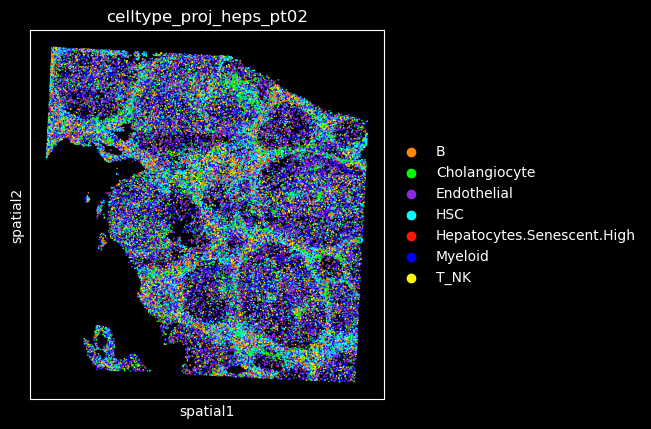

In [170]:
sc.pl.spatial(
    adata_heps_sen_other_ct,
    color="celltype_proj_heps_pt02",
    palette=neon_rainbow_colors_broad_grey,  # Customize colors
    size=4,
    img_key=None,
    show = False
)
plt.savefig(f"{odir}pt02_sen_high_cells_other_ct.pdf")

/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


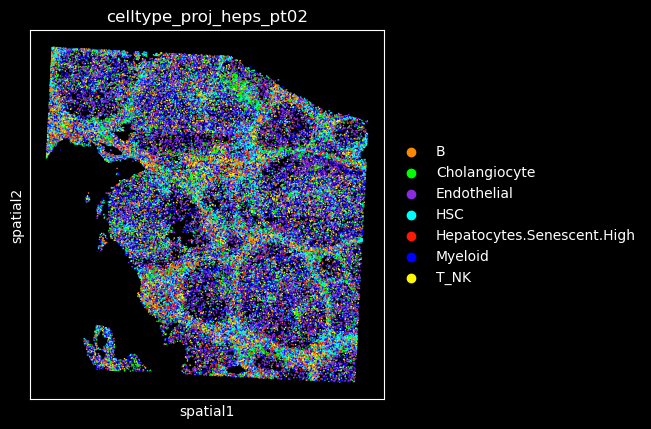

In [171]:
# Define the target cell type you want to appear on top
target_celltype = "Hepatocytes.Senescent.High"

# Sort so that the target cell type is last
adata_sorted = adata_heps_sen_other_ct[
   adata_heps_sen_other_ct.obs.sort_values(by="celltype_proj_heps_pt02", key=lambda x: x != target_celltype, ascending =False).index
]

# Plot the reordered data
sc.pl.spatial(
    adata_sorted,
    color="celltype_proj_heps_pt02",
    palette=neon_rainbow_colors_broad_grey,  # Customize colors
    size=4,
    img_key=None,
    show = False
)
plt.savefig(f"{odir}pt02_sen_high_cells_other_ct_top.pdf")